# Description

In this notebook, the composition of the "corpus" is shown. 
For each scraped university it shows:
- How many events were extracted
- How many of them have a content element
- for how many semesters and which

The notebook takes the courses.csv file as an input and outputs two figures into the figure-folder.

In [1]:
import pandas as pd
import plotly.express as px
import numpy as np
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import glob
import re

## Configure Data

In [2]:
# since the semesters are meant to be shown in a certain order later, this order is specified here.
all_semesters = ['wise00-01', 'sose01', 'wise01-02', 'sose02', 'wise02-03', 'sose03', \
                 'wise03-04', 'sose04', 'wise04-05', 'sose05', 'wise05-06', 'sose06', \
                 'wise06-07', 'sose07', 'wise07-08', 'sose08', 'wise08-09', 'sose09',\
                 'wise09-10', 'sose10', 'wise10-11', 'sose11', 'wise11-12', 'sose12', \
                 'wise12-13', 'sose13', 'wise13-14', 'sose14', 'wise14-15', 'sose15', \
                 'wise15-16', 'sose16', 'wise16-17', 'sose17', 'wise17-18', 'sose18',\
                 'wise18-19', 'sose19', 'wise19-20', 'sose20', 'wise20-21', 'sose21', \
                 'wise21-22', 'sose22', 'wise22-23', 'sose23', 'wise23-24']

In [3]:
# The data/course.csv table is read in as input since it stores the counts of course titles und descriptions scraped from the catalogs.

data = pd.read_csv("data/courses.csv", sep=";", encoding="utf-8", index_col=0)

data["titel_count"] = 1
df = pd.DataFrame()
df["semester"] = all_semesters
unis = ["wien", "graz", "basel", "chemnitz", "erfurt", "halle", "marburg", "mainz", "stuttgart"]

for uni in unis:
    uni_df = data[data["university"] == uni]
    
    unigrouped = uni_df.groupby("semester").sum(["inhalt_count", "titel_count"])
   

    title_per_sem = []
    inhalt_per_sem = []
    for sem in all_semesters:
        
        if sem in unigrouped.index:
            title_per_sem.append(unigrouped["titel_count"].loc[sem])
            
            if unigrouped["inhalt_count"].loc[sem] > 0:
                inhalt_per_sem.append(unigrouped["inhalt_count"].loc[sem])
            else:
                inhalt_per_sem.append(0)
        else:
            title_per_sem.append(0)
            inhalt_per_sem.append(0)
            
    df["Titel_"+uni] = title_per_sem
    df["Inhalt_"+uni] = inhalt_per_sem


# Visualizations

## Figure 1 (course descriptions and course titles)

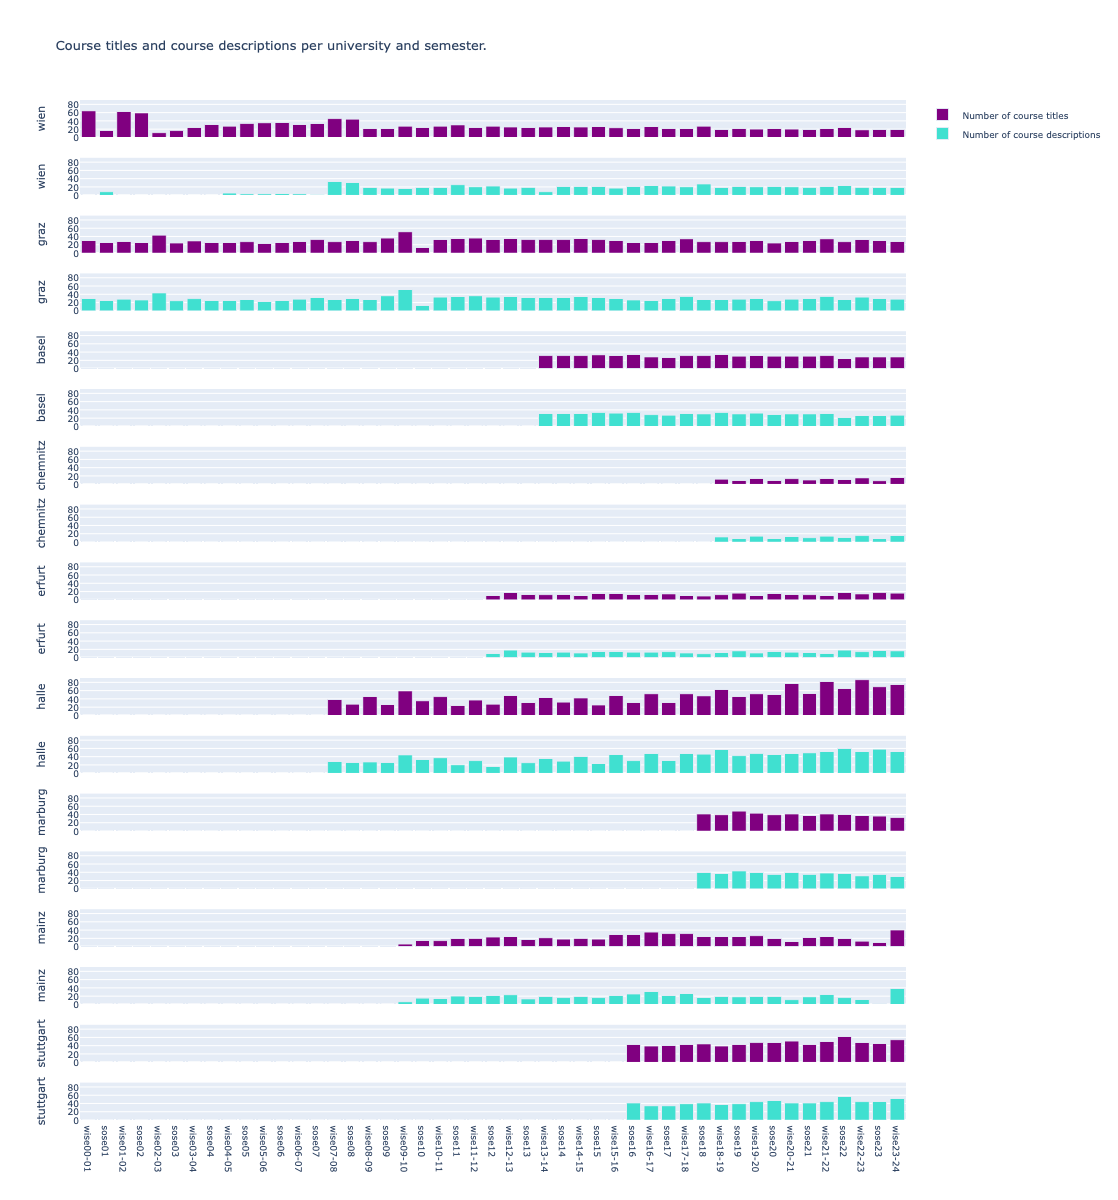

In [12]:
columns = [col for col in df.columns if "semester" not in col]
fig = make_subplots(rows=len(columns), cols=1, shared_xaxes=True, vertical_spacing=0.02, shared_yaxes='all')

rowcounter = 1

for col in columns:
    if rowcounter > 2:
        show_legend = False
    else:
        show_legend = True
    
    stadt = col.split("_")[1]
    content = col.split("_")[0]
    
    if content == "Titel":
        name = "Number of course titles"
        color="purple"
    else:
        name = "Number of course descriptions"
        color="turquoise"
    
    
    fig.add_bar(
        x=df.semester.to_list(),
        y=df[col].to_list(),
        marker=dict(color=color),
        #mode="markers",
        name=name,
        row=rowcounter, col=1,\
        showlegend= show_legend)
    
    axis = "yaxis" + str(rowcounter)
    fig['layout'][axis]['title']= stadt
    rowcounter+=1

fig.update_layout(height=1200)

fig.update_layout(
    title="Course titles and course descriptions per university and semester.",
    font=dict(
        size=9,
    ))
fig.write_image("figures/total_numbers1.png", scale=2)
fig.show()

# Figure 2 (only course descriptions)

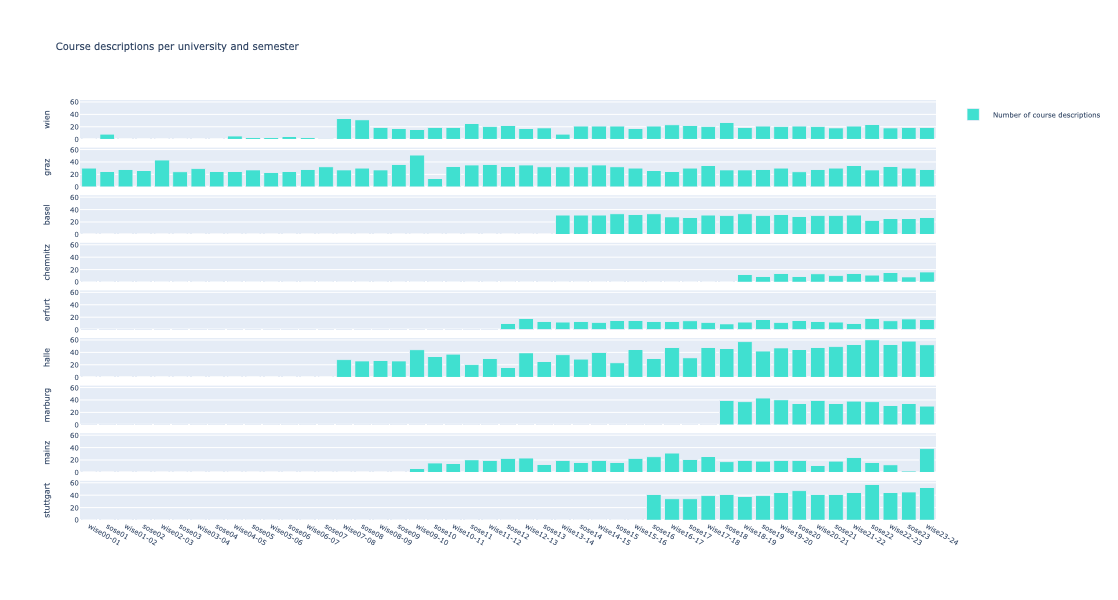

In [13]:
columns = [col for col in df.columns if "semester" not in col and "Titel" not in col]
fig = make_subplots(rows=len(columns), cols=1, shared_xaxes=True, vertical_spacing=0.02, shared_yaxes='all')

rowcounter = 1

for col in columns:
    if rowcounter > 1:
        show_legend = False
    else:
        show_legend = True
    
    stadt = col.split("_")[1]
    name = "Number of course descriptions"
    color="turquoise"
    
    fig.add_bar(
        x=df.semester.to_list(),
        y=df[col].to_list(),
        marker=dict(color=color),
        name=name,
        row=rowcounter, col=1,\
        showlegend= show_legend)
    axis = "yaxis" + str(rowcounter)
    fig['layout'][axis]['title']= stadt
    rowcounter+=1

fig.update_layout(height=600)

fig.update_layout(
    title="Course descriptions per university and semester",
    font=dict(
        size=7,
    ))

fig.write_image("figures/total_numbers2.png", scale=2)
fig.show()